# P13 - Explainability SHAP

Analyse globale et locale des facteurs qui influencent les predictions de modeles.

In [1]:
from pathlib import Path
import sys

import joblib
import pandas as pd
import plotly.express as px
import shap

if Path('/app/src').exists():
    sys.path.insert(0, '/app/src')
    models_dir = Path('/app/models')
else:
    sys.path.insert(0, '../../src')
    models_dir = Path('../../models')

from p13.db import read_sql
from p13.ml.features import FEATURE_COLUMNS

In [2]:
target = 'nb_eleves_elementaire'
model_path = models_dir / f'{target}_best.joblib'

if not model_path.exists():
    raise FileNotFoundError(f'Modele non trouve: {model_path}. Lancez /ml/train avant SHAP.')

model = joblib.load(model_path)
df = read_sql('SELECT * FROM ml_dataset_commune ORDER BY rentree, code_insee')
df = df.dropna(subset=FEATURE_COLUMNS + [target]).copy()
X = df[FEATURE_COLUMNS]
X.shape

(688, 9)

In [3]:
sample_size = min(400, len(X))
X_sample = X.sample(sample_size, random_state=42) if len(X) > sample_size else X.copy()
X_sample_np = X_sample.to_numpy()

try:
    explainer = shap.Explainer(model, X_sample_np, feature_names=FEATURE_COLUMNS)
    shap_values = explainer(X_sample_np)
except Exception:
    background = shap.sample(X_sample_np, min(100, len(X_sample_np)), random_state=42)
    explainer = shap.KernelExplainer(lambda arr: model.predict(arr), background)
    shap_values = explainer.shap_values(X_sample_np, nsamples=100)

'SHAP calcule sur ' + str(len(X_sample_np)) + ' lignes'

'SHAP calcule sur 400 lignes'

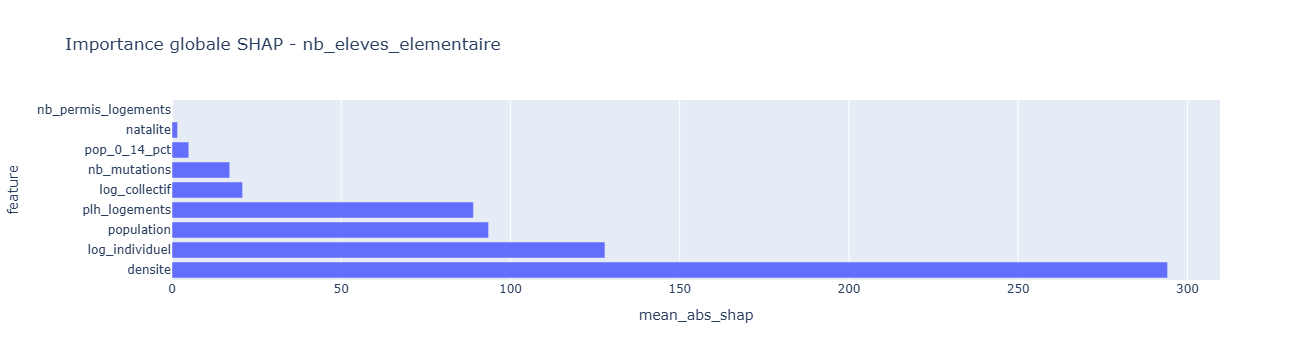

,feature,mean_abs_shap
3,densite,294.137165
5,log_individuel,127.908565
0,population,93.534551
6,plh_logements,89.062928
4,log_collectif,20.860975
7,nb_mutations,17.058563
1,pop_0_14_pct,4.961389
2,natalite,1.633791
8,nb_permis_logements,0.000000


In [4]:
if hasattr(shap_values, 'values'):
    values = shap_values.values
else:
    values = shap_values

importance = pd.DataFrame({
    'feature': FEATURE_COLUMNS,
    'mean_abs_shap': pd.DataFrame(values, columns=FEATURE_COLUMNS).abs().mean().values
}).sort_values('mean_abs_shap', ascending=False)

fig = px.bar(
    importance.head(15),
    x='mean_abs_shap',
    y='feature',
    orientation='h',
    title=f'Importance globale SHAP - {target}'
)
fig.show()
importance

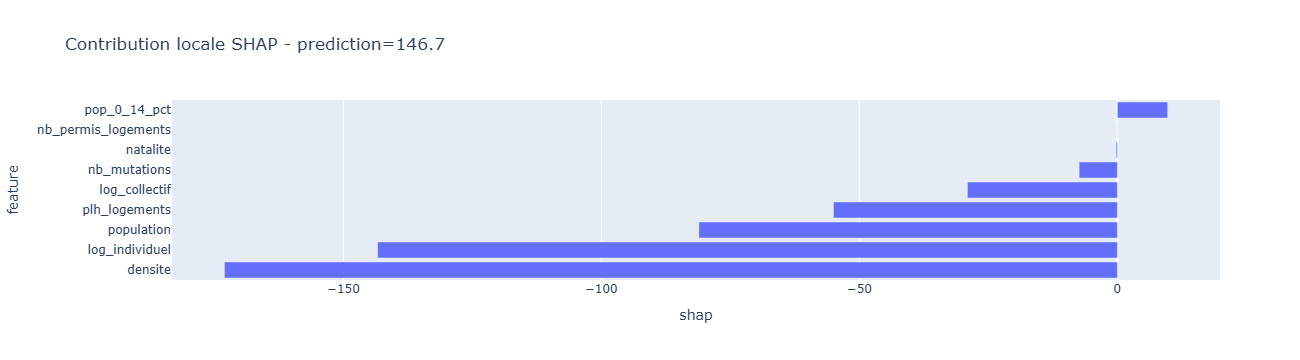

,feature,value,shap
3,densite,374.0,-173.072346
5,log_individuel,521.0,-143.376598
0,population,1793.0,-81.111666
6,plh_logements,102.0,-55.021682
4,log_collectif,13.0,-29.062394
7,nb_mutations,522.0,-7.402777
2,natalite,13.4,-0.233407
8,nb_permis_logements,0.0,0.000000
1,pop_0_14_pct,27.7,9.742928


In [5]:
idx = 0
row = X_sample.iloc[[idx]]
row_np = row.to_numpy()
pred = float(model.predict(row_np)[0])

local = pd.DataFrame({
    'feature': FEATURE_COLUMNS,
    'value': row_np[0]
})

if hasattr(shap_values, 'values'):
    local['shap'] = shap_values.values[idx]
else:
    local['shap'] = values[idx]

local = local.sort_values('shap')
fig_local = px.bar(local, x='shap', y='feature', orientation='h', title=f'Contribution locale SHAP - prediction={pred:.1f}')
fig_local.show()
local